# 00 - понять LIBERO как LeRobotDataset

Цель notebook: не обучать модель, а руками посмотреть, что такое демонстрация в LIBERO: `task`, `episode`, `observation.images.*`, `observation.state`, `action`, `timestamp`.

Полезные источники:
- [LeRobot LIBERO docs](https://huggingface.co/docs/lerobot/main/libero)
- [LeRobotDataset docs в коде LeRobot](https://github.com/huggingface/lerobot)
- [SmolVLA docs](https://huggingface.co/docs/lerobot/main/smolvla)
- [HuggingFaceVLA/libero](https://huggingface.co/datasets/HuggingFaceVLA/libero)

Так как просят использовать HuggingFaceVLA/libero, то скачаем его. Хотя в документации указано, что предпочтительно скачивать в виде видео.

In [64]:
import os
os.environ["HF_XET_HIGH_PERFORMANCE"] = "1"

from tqdm import tqdm_notebook
from datasets import load_dataset
from pathlib import Path
from PIL import Image

ROOT_DIR = Path.cwd().resolve().parent
DATA_DIR = ROOT_DIR / "data"
DATA_DIR.mkdir(exist_ok=True, parents=True)


In [2]:
from huggingface_hub import login, whoami

login()
whoami()

{'type': 'user',
 'id': '6750aa2ffbf282a46e1cf067',
 'name': 'ne24kit',
 'fullname': 'Efimov Nikita',
 'canPay': False,
 'billingMode': 'prepaid',
 'periodEnd': 1788220800,
 'isPro': False,
 'avatarUrl': '/avatars/556833aa80dd746def9a37a2cf84b1a5.svg',
 'orgs': [],
 'auth': {'type': 'oauth', 'expiresAt': '2026-09-07T11:55:04.000Z'}}

В задании просят работать с `libero_90` и `libero_goal` (`task_ids`=0,1,2). \
Значит скачаем их ниже

In [3]:
from huggingface_hub import snapshot_download

RAW_ROOT = ROOT_DIR / "libero_hdf5"
RAW_ROOT.mkdir(exist_ok=True, parents=True)

snapshot_download(
    repo_id="yifengzhu-hf/LIBERO-datasets",
    repo_type="dataset",
    local_dir=str(RAW_ROOT),
    allow_patterns=[
        "libero_90/*.hdf5",
        "libero_goal/*.hdf5",
    ],
    token=True,
    max_workers=16,
)

Fetching 100 files: 100%|██████████| 100/100 [57:51<00:00, 34.72s/it] 


'/home/msi/projects/TrainerVLA/libero_hdf5'

In [4]:

seen_files = sorted((RAW_ROOT / "libero_90").glob("*.hdf5"))
goal_files = sorted((RAW_ROOT / "libero_goal").glob("*.hdf5"))

len(seen_files), len(goal_files)

(90, 10)

In [14]:
from libero.libero import benchmark

benchmarks = benchmark.get_benchmark_dict()
goal_suite = benchmarks["libero_goal"]()

for task_id in [0, 1, 2]:
    task = goal_suite.get_task(task_id)
    print(task)
    print(task_id)
    print("name:", task.name)
    print("language:", task.language)
    path = RAW_ROOT / "libero_goal" / f"{task.name}_demo.hdf5"
    print("is exist: ", path.exists())


[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Task(name='open_the_middle_drawer_of_the_cabinet', language='open the middle drawer of the cabinet', problem='Libero', problem_folder='libero_goal', bddl_file='open_the_middle_drawer_of_the_cabinet.bddl', init_states_file='open_the_middle_drawer_of_the_cabinet.pruned_init')
0
name: open_the_middle_drawer_of_the_cabinet
language: open the middle drawer of the cabinet
is exist:  True
Task(name='put_the_bowl_on_the_stove', language='put the bowl on the stove', problem='Libero', problem_folder='libero_goal', bddl_file='put_the_bowl_on_the_stove.bddl', init_states_file='put_the_bowl_on_the_stove.pruned_init')
1
name: put_the_bowl_on_the_stove
language: put the bowl on the stove
is exist:  True
Task(name='put_the_wine_bottle_on_top_of_the_cabinet', language='put the wine bottle on top of the cabinet', problem='Libero', problem_folder='libero_goal', bddl_file='put_the_wine_bottle_on_top_of_the_cabinet.bddl', init_states_file='put_the_win

In [17]:
seen_files = sorted((RAW_ROOT / "libero_90").glob("*.hdf5"))

target_task_names = [
    "open_the_middle_drawer_of_the_cabinet",      # task_id 0
    "put_the_bowl_on_the_stove",                 # task_id 1
    "put_the_wine_bottle_on_top_of_the_cabinet", # task_id 2
]

target_files = [
    RAW_ROOT / "libero_goal" / f"{name}_demo.hdf5"
    for name in target_task_names
]

print("seen libero_90 files:", len(seen_files))
print("target libero_goal files:", len(target_files))

seen libero_90 files: 90
target libero_goal files: 3


In [33]:
import h5py

for pth in target_files:
    with h5py.File(pth, "r") as f:
        # print("Keys:", list(f.keys()))
        print(f"{len(f['data'])} {pth.name}")

  
# for pth in seen_files:
for pth in seen_files[:3]:
    with h5py.File(pth, "r") as f:
        # print("Keys:", list(f.keys()))
        print(f"{len(f['data'])} {pth.name}")
  

50 open_the_middle_drawer_of_the_cabinet_demo.hdf5
50 put_the_bowl_on_the_stove_demo.hdf5
50 put_the_wine_bottle_on_top_of_the_cabinet_demo.hdf5
50 KITCHEN_SCENE10_close_the_top_drawer_of_the_cabinet_and_put_the_black_bowl_on_top_of_it_demo.hdf5
50 KITCHEN_SCENE10_close_the_top_drawer_of_the_cabinet_demo.hdf5
50 KITCHEN_SCENE10_put_the_black_bowl_in_the_top_drawer_of_the_cabinet_demo.hdf5


Знaчит в каждой такой сцене по 50 demo

In [52]:
pth = target_files[0]
with h5py.File(pth, "r") as f:
    print(f['data'].keys())
    demos = sorted(f["data"].keys(), key=lambda x: int(x.split("_")[-1]))
    demo_key = demos[0]
    print(f['data'][demo_key].keys())
    demo_data = f['data'][demo_key]
    for elem in demo_data.keys():
        print(demo_data[elem])
        if elem == "obs":
            print("obs info")
            print(4*" ", demo_data[elem].keys())
            for obs_elem in demo_data[elem].keys():
                print(8*" ", obs_elem, demo_data[elem][obs_elem])


<KeysViewHDF5 ['demo_0', 'demo_1', 'demo_10', 'demo_11', 'demo_12', 'demo_13', 'demo_14', 'demo_15', 'demo_16', 'demo_17', 'demo_18', 'demo_19', 'demo_2', 'demo_20', 'demo_21', 'demo_22', 'demo_23', 'demo_24', 'demo_25', 'demo_26', 'demo_27', 'demo_28', 'demo_29', 'demo_3', 'demo_30', 'demo_31', 'demo_32', 'demo_33', 'demo_34', 'demo_35', 'demo_36', 'demo_37', 'demo_38', 'demo_39', 'demo_4', 'demo_40', 'demo_41', 'demo_42', 'demo_43', 'demo_44', 'demo_45', 'demo_46', 'demo_47', 'demo_48', 'demo_49', 'demo_5', 'demo_6', 'demo_7', 'demo_8', 'demo_9']>
<KeysViewHDF5 ['actions', 'dones', 'obs', 'rewards', 'robot_states', 'states']>
<HDF5 dataset "actions": shape (138, 7), type "<f8">
<HDF5 dataset "dones": shape (138,), type "|u1">
<HDF5 group "/data/demo_0/obs" (7 members)>
obs info
     <KeysViewHDF5 ['agentview_rgb', 'ee_ori', 'ee_pos', 'ee_states', 'eye_in_hand_rgb', 'gripper_states', 'joint_states']>
         agentview_rgb <HDF5 dataset "agentview_rgb": shape (138, 128, 128, 3), type 

Изучим то, что есть и за что отвечает

In [ ]:
from time import sleep
from IPython.display import display, clear_output

with h5py.File(pth, "r") as f:
    
    demos = sorted(f["data"].keys(), key=lambda x: int(x.split("_")[-1]))
    demo_key = demos[0]
    demo_data = f['data'][demo_key]
    
    agentview_rgb = demo_data["obs"]["agentview_rgb"][:]
    eye_in_hand_rgb = demo_data["obs"]["eye_in_hand_rgb"][:]

    ee_ori = demo_data["obs"]["eye_in_hand_rgb"][:]
    ee_pos = demo_data["obs"]["ee_pos"][:]
    ee_states = demo_data["obs"]["ee_states"][:]
    gripper_states = demo_data["obs"]["gripper_states"][:]
    joint_states = demo_data["obs"]["joint_states"][:]
      

Я так понял это вид с статичной камеры

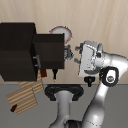

In [ ]:
for i in range(len(agentview_rgb)):
    clear_output(wait=True)
    display(Image.fromarray(agentview_rgb[i]))
    sleep(1 / 20)  # 20 fps

А это уже вид камеры с робо руки

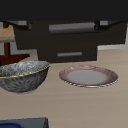

In [85]:
for i in range(len(agentview_rgb)):
    clear_output(wait=True)
    display(Image.fromarray(eye_in_hand_rgb[i]))
    sleep(1 / 20)  # 20 fps

Но названия не совпадают с тем как представлен датасет libero в lerobot.

Я попробую сделать matching и проверить те ли это цифры и позиции, также попробую преобразовать датасет.